# Inverted-pendulum distillation comparison

Five-seed comparisons of linear regression and symbolic students under Uniform and Q-DAgger weighting. Dashed reward lines mark the 999 threshold.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
cwd = Path.cwd().resolve()
ROOT = next(path for path in (cwd, *cwd.parents) if (path / 'distillation_experiments').is_dir())
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
EXP = ROOT / 'distillation_experiments'
ADAM_DIR = EXP / 'artifacts' / 'repertoires/cgp_expression_adam_inverted_pendulum/expression_adam_5seeds'
Q_ADAM_DIR = EXP / 'artifacts' / 'repertoires/cgp_expression_adam_inverted_pendulum/expression_adam_qdagger_5seeds'
GEN_ADAM_DIR = EXP / 'artifacts' / 'repertoires/cgp_expression_adam_inverted_pendulum/cgp_generation_adam_uniform_5seeds'
Q_GEN_ADAM_DIR = EXP / 'artifacts' / 'repertoires/cgp_expression_adam_inverted_pendulum/cgp_generation_adam_qdagger_5seeds'
SCALING_DIR = EXP / 'artifacts' / 'repertoires/dagger_inverted_pendulum/cgp_linear_scaling_bc_5seeds'
LINEAR_DIR = EXP / 'artifacts' / 'repertoires/dagger_linear_inverted_pendulum/linear_5seeds_test_split'
Q_LINEAR_DIR = EXP / 'artifacts' / 'repertoires/dagger_linear_inverted_pendulum/linear_qdagger_5seeds_test_split'
PYSR_DIR = EXP / 'artifacts' / 'repertoires/pysr_inverted_pendulum/pysr_tracked_5seeds'
OPERON_DIR = EXP / 'artifacts' / 'repertoires/operon_inverted_pendulum/operon_tracked_5seeds'

def read_json(path):
    with path.open() as file:
        return json.load(file)

linear = pd.DataFrame(read_json(LINEAR_DIR / 'aggregate_summary.json')['seeds'])
q_linear = pd.DataFrame(read_json(Q_LINEAR_DIR / 'aggregate_summary.json')['seeds'])
scaling = pd.DataFrame(read_json(SCALING_DIR / 'aggregate_summary.json')['seeds'])
adam = pd.DataFrame(read_json(ADAM_DIR / 'aggregate_summary.json')['variants'])
q_adam = pd.DataFrame(read_json(Q_ADAM_DIR / 'aggregate_summary.json')['variants'])
generation_adam = pd.DataFrame(read_json(GEN_ADAM_DIR / 'aggregate_summary.json')['variants'])
q_generation_adam = pd.DataFrame(read_json(Q_GEN_ADAM_DIR / 'aggregate_summary.json')['variants'])
pysr_results = pd.DataFrame(read_json(PYSR_DIR / 'aggregate_summary.json')['variants'])
operon_results = pd.DataFrame(read_json(OPERON_DIR / 'aggregate_summary.json')['variants'])
candidate_frames = []
for path in sorted(ADAM_DIR.glob('seed_*/*/candidates.json')):
    frame = pd.DataFrame(read_json(path))
    frame['seed'] = int(path.parents[1].name.split('_')[1])
    frame['mode'] = path.parent.name
    candidate_frames.append(frame)
candidates = pd.concat(candidate_frames, ignore_index=True)
generation_candidate_frames = []
for path in sorted(GEN_ADAM_DIR.glob('seed_*/*/candidates.json')):
    frame = pd.DataFrame(read_json(path))
    frame['seed'] = int(path.parents[1].name.split('_')[1])
    frame['mode'] = path.parent.name
    generation_candidate_frames.append(frame)
generation_candidates = pd.concat(generation_candidate_frames, ignore_index=True)
q_generation_candidate_frames = []
for path in sorted(Q_GEN_ADAM_DIR.glob('seed_*/*/candidates.json')):
    frame = pd.DataFrame(read_json(path))
    frame['seed'] = int(path.parents[1].name.split('_')[1])
    frame['mode'] = path.parent.name
    q_generation_candidate_frames.append(frame)
q_generation_candidates = pd.concat(q_generation_candidate_frames, ignore_index=True)
q_candidate_frames = []
for path in sorted(Q_ADAM_DIR.glob('seed_*/*/candidates.json')):
    frame = pd.DataFrame(read_json(path))
    frame['seed'] = int(path.parents[1].name.split('_')[1])
    frame['mode'] = path.parent.name
    q_candidate_frames.append(frame)
q_candidates = pd.concat(q_candidate_frames, ignore_index=True)
sr_training_loss = {}
for engine, root, loss_column in [('PySR', PYSR_DIR, 'pysr_loss'), ('Operon', OPERON_DIR, 'operon_mse')]:
    summaries = pysr_results if engine == 'PySR' else operon_results
    for row in summaries.itertuples():
        table = pd.read_csv(root / f'seed_{row.seed}' / row.mode / 'candidates.csv')
        selected = table.loc[table.position == row.selected_position].iloc[0]
        sr_training_loss[(engine, row.seed, row.mode)] = float(selected[loss_column])


In [2]:
# Data preparation shared by the remaining plots; this cell produces no output.
comparison_rows = []
for weighting, frame in [('DAgger', linear), ('Q-DAgger', q_linear)]:
    for row in frame.itertuples():
        comparison_rows.append(dict(policy='Linear', weighting=weighting, seed=row.seed,
                                    reward=row.final_reward, test_loss=row.final_test_imitation_loss))
for policy, frame in [('PySR', pysr_results), ('Operon', operon_results)]:
    for row in frame.itertuples():
        comparison_rows.append(dict(policy=policy, weighting='Q-DAgger' if row.mode == 'q_dagger' else 'DAgger',
                                    seed=row.seed, reward=row.reward, test_loss=row.validation_mse))
for weighting, frame, generation_frame in [('DAgger', adam, generation_adam),
                                          ('Q-DAgger', q_adam, q_generation_adam)]:
    for row in frame.itertuples():
        comparison_rows.append(dict(policy=f'CGP {row.mode} pre-Adam', weighting=weighting, seed=row.seed,
                                    reward=row.best_reward_before_adam, test_loss=row.best_validation_mse_before_adam))
    for row in generation_frame.itertuples():
        comparison_rows.append(dict(policy=f'CGP {row.mode} generation-Adam', weighting=weighting, seed=row.seed,
                                    reward=row.best_reward_after_adam, test_loss=row.best_validation_mse_after_adam))
comparison = pd.DataFrame(comparison_rows)

history_frames = []
for engine, root, step_column in [('PySR', PYSR_DIR, 'iteration'), ('Operon', OPERON_DIR, 'generation')]:
    for path in sorted(root.glob('seed_*/*/search_history.csv')):
        frame = pd.read_csv(path).rename(columns={step_column: 'step'})
        frame['method'] = engine
        frame['seed'] = int(path.parents[1].name.split('_')[1])
        frame['weighting'] = 'Q-DAgger' if path.parent.name == 'q_dagger' else 'DAgger'
        history_frames.append(frame)
for weighting, root, suffix in [
    ('DAgger', EXP / 'artifacts' / 'repertoires/cgp_expression_adam_inverted_pendulum/cgp_loss_history_uniform_5seeds', ''),
    ('Q-DAgger', EXP / 'artifacts' / 'repertoires/cgp_expression_adam_inverted_pendulum/cgp_loss_history_qdagger_5seeds', ''),
    ('DAgger', GEN_ADAM_DIR, ' + generation Adam'),
    ('Q-DAgger', Q_GEN_ADAM_DIR, ' + generation Adam'),
]:
    for path in sorted(root.glob('seed_*/*/search_history.csv')):
        frame = pd.read_csv(path).rename(columns={'generation': 'step'})
        frame['method'] = f'CGP {path.parent.name}{suffix}'
        frame['seed'] = int(path.parents[1].name.split('_')[1])
        frame['weighting'] = weighting
        history_frames.append(frame)
combined_history = pd.concat(history_frames, ignore_index=True)
colors = {'PySR': '#4C72B0', 'Operon': '#55A868', 'CGP raw': '#C44E52',
          'CGP scaled': '#8172B3', 'CGP raw + generation Adam': '#CCB974',
          'CGP scaled + generation Adam': '#64B5CD'}


## Combined symbolic-search loss progression

Curves show median best training loss; bands span seeds. Search steps are native to each engine and do not represent equal compute.


## Stacked loss progression and final-loss distributions

Rows separate weighting objectives. Curves show search progression; boxplots show final tracked losses across seeds.


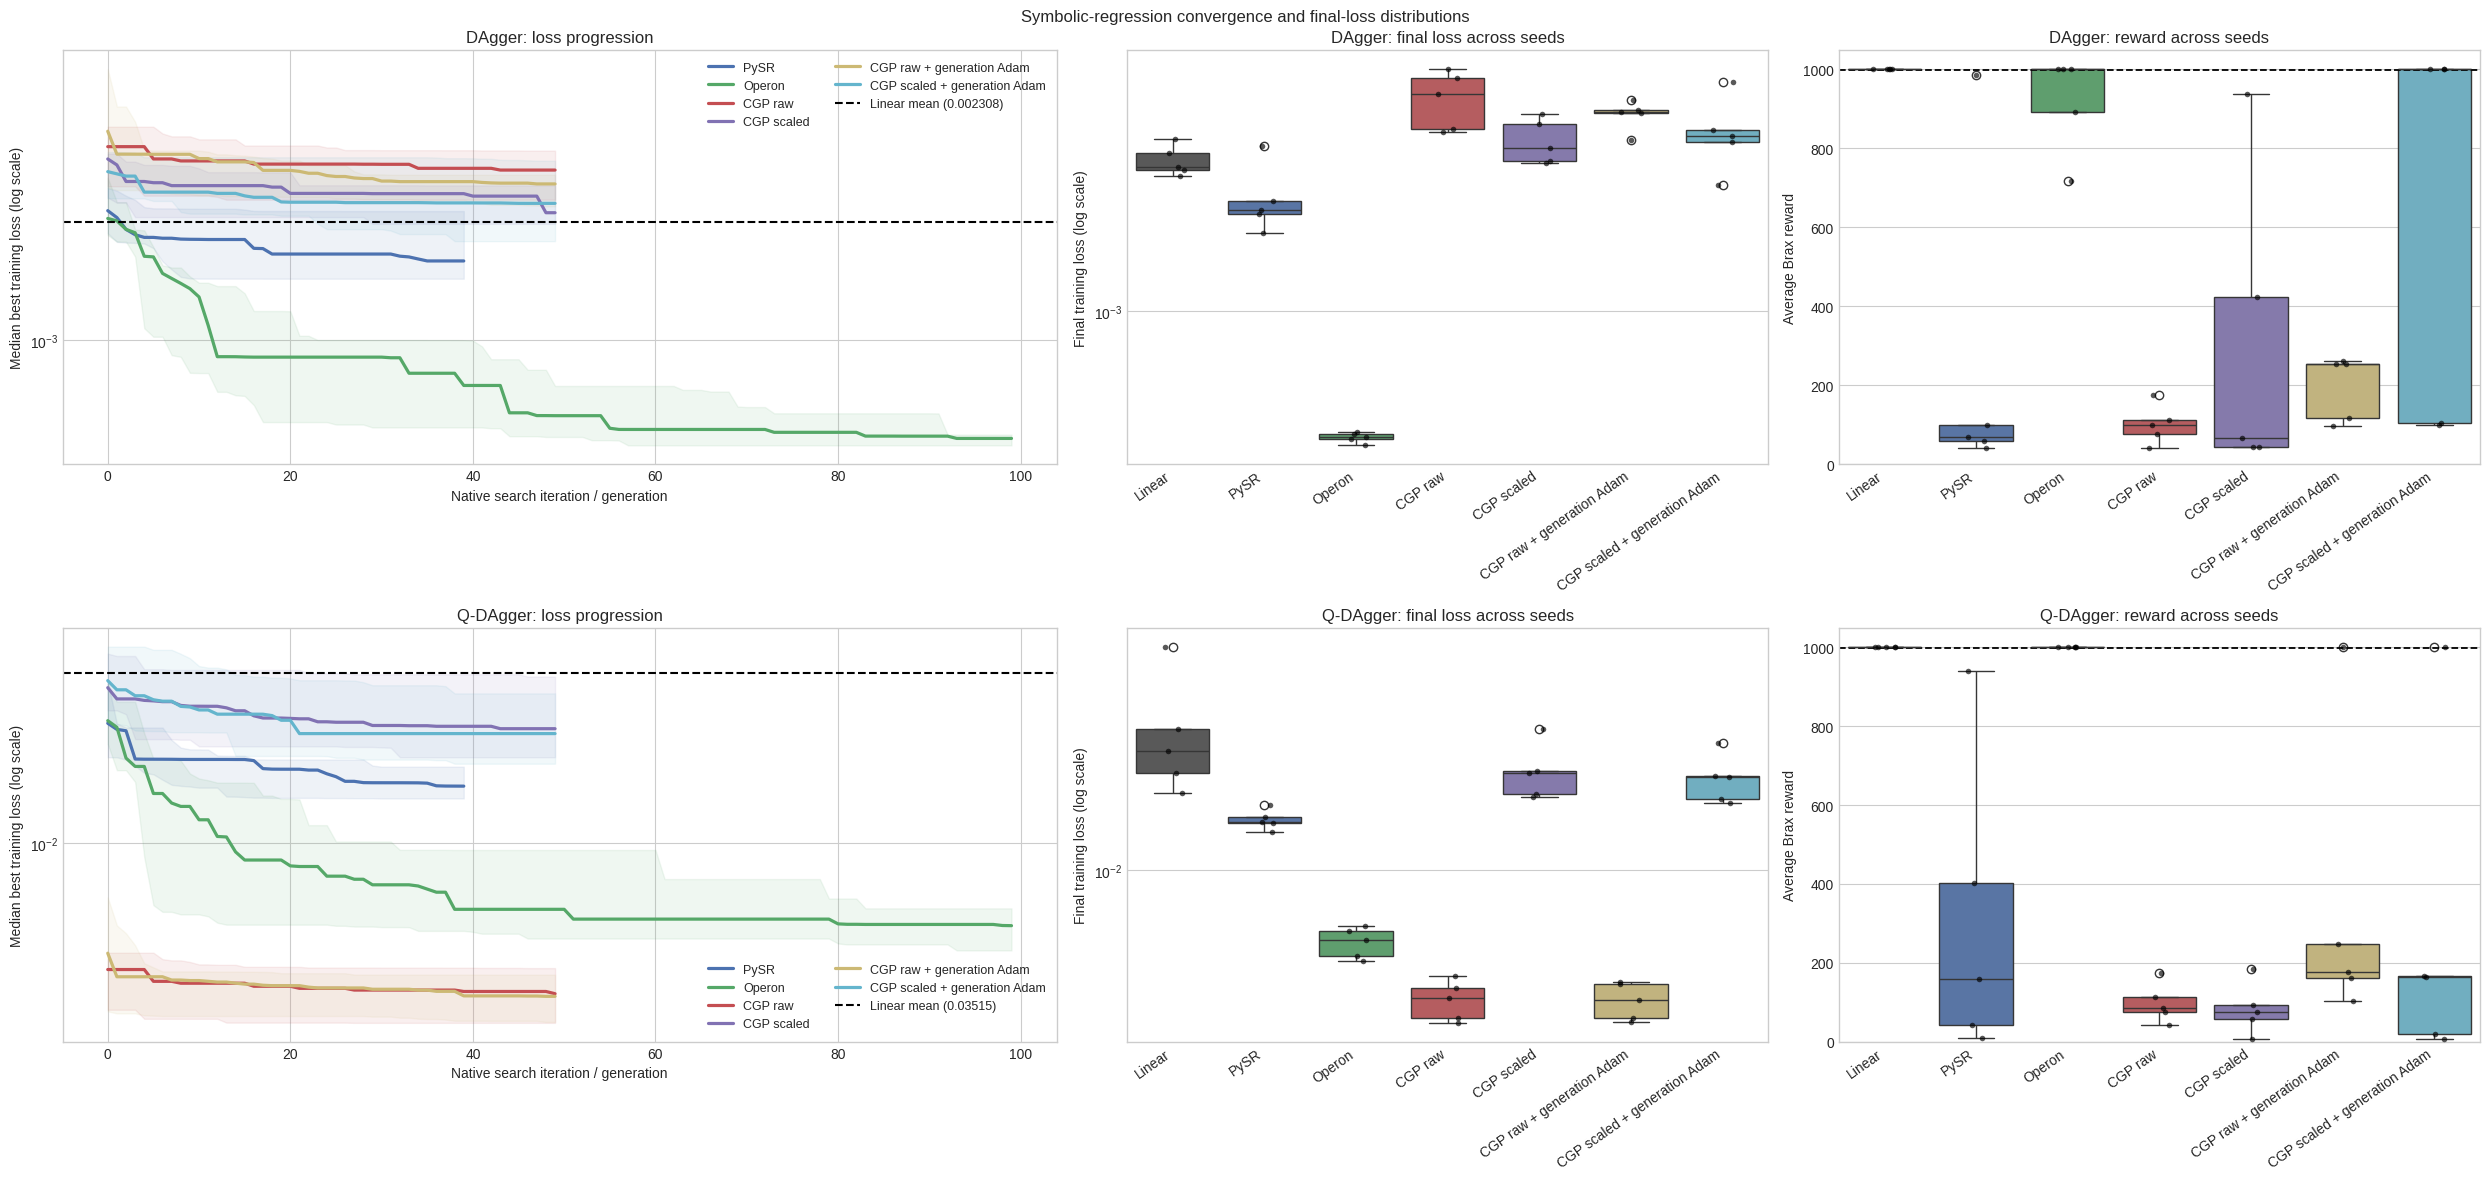

In [3]:
import seaborn as sns

method_order = ['Linear', 'PySR', 'Operon', 'CGP raw', 'CGP scaled', 'CGP raw + generation Adam', 'CGP scaled + generation Adam']
distribution_frames = []
for (weighting, method, seed), frame in combined_history.groupby(['weighting', 'method', 'seed']):
    final_row = frame.loc[frame.step.idxmax()]
    distribution_frames.append({'weighting': weighting, 'method': method, 'seed': seed, 'loss': final_row.best_loss})
for weighting, frame in [('DAgger', linear), ('Q-DAgger', q_linear)]:
    for row in frame.itertuples():
        distribution_frames.append({'weighting': weighting, 'method': 'Linear', 'seed': row.seed, 'loss': row.final_imitation_loss})
final_loss_distribution = pd.DataFrame(distribution_frames)
box_colors = {'Linear': '0.35', **colors}

reward_policy_map = {'Linear': 'Linear', 'PySR': 'PySR', 'Operon': 'Operon', 'CGP raw': 'CGP raw pre-Adam', 'CGP scaled': 'CGP scaled pre-Adam', 'CGP raw + generation Adam': 'CGP raw generation-Adam', 'CGP scaled + generation Adam': 'CGP scaled generation-Adam'}
reward_frames = []
for method, policy in reward_policy_map.items():
    frame = comparison[comparison.policy == policy][['weighting', 'seed', 'reward']].copy()
    frame['method'] = method
    reward_frames.append(frame)
reward_distribution = pd.concat(reward_frames, ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(25, 12), gridspec_kw={'width_ratios': [1.55, 1, 1]})
for row_index, weighting in enumerate(['DAgger', 'Q-DAgger']):
    line_ax, box_ax, reward_ax = axes[row_index]
    for method in method_order[1:]:
        subset = combined_history[(combined_history.weighting == weighting) & (combined_history.method == method)]
        if subset.empty:
            continue
        aggregate = subset.groupby('step').best_loss.agg(['median', 'min', 'max'])
        line_ax.plot(aggregate.index, aggregate['median'], color=colors[method], linewidth=2.3, label=method)
        line_ax.fill_between(aggregate.index, aggregate['min'], aggregate['max'], color=colors[method], alpha=0.09)
    linear_values = (linear if weighting == 'DAgger' else q_linear).final_imitation_loss
    linear_mean = linear_values.mean()
    line_ax.axhline(linear_mean, color='black', linestyle='--', linewidth=1.5, label=f'Linear mean ({linear_mean:.4g})')
    line_ax.set_yscale('log')
    line_ax.set(title=f'{weighting}: loss progression', xlabel='Native search iteration / generation', ylabel='Median best training loss (log scale)')
    line_ax.legend(fontsize=9, ncol=2)

    box_data = final_loss_distribution[final_loss_distribution.weighting == weighting]
    present_order = [method for method in method_order if method in set(box_data.method)]
    sns.boxplot(data=box_data, x='method', y='loss', order=present_order, palette=box_colors, showfliers=True, whis=1.5, ax=box_ax)
    sns.stripplot(data=box_data, x='method', y='loss', order=present_order, color='black', size=4, alpha=0.65, jitter=0.12, ax=box_ax)
    box_ax.set_yscale('log')
    box_ax.set(title=f'{weighting}: final loss across seeds', xlabel='', ylabel='Final training loss (log scale)')
    box_ax.tick_params(axis='x', rotation=35)
    for label in box_ax.get_xticklabels():
        label.set_horizontalalignment('right')

    reward_data = reward_distribution[reward_distribution.weighting == weighting]
    reward_order = [method for method in method_order if method in set(reward_data.method)]
    sns.boxplot(data=reward_data, x='method', y='reward', order=reward_order, palette=box_colors, showfliers=True, whis=1.5, ax=reward_ax)
    sns.stripplot(data=reward_data, x='method', y='reward', order=reward_order, color='black', size=4, alpha=0.65, jitter=0.12, ax=reward_ax)
    reward_ax.axhline(999, color='black', linestyle='--', linewidth=1.3, label='Solved threshold')
    reward_ax.set(title=f'{weighting}: reward across seeds', xlabel='', ylabel='Average Brax reward')
    reward_ax.set_ylim(bottom=0)
    reward_ax.tick_params(axis='x', rotation=35)
    for label in reward_ax.get_xticklabels():
        label.set_horizontalalignment('right')
fig.suptitle('Symbolic-regression convergence and final-loss distributions')
plt.tight_layout(); plt.show()

## Final training loss, held-out loss, and reward distributions

Five-seed distributions of training loss, held-out loss and reward, separated by weighting objective.


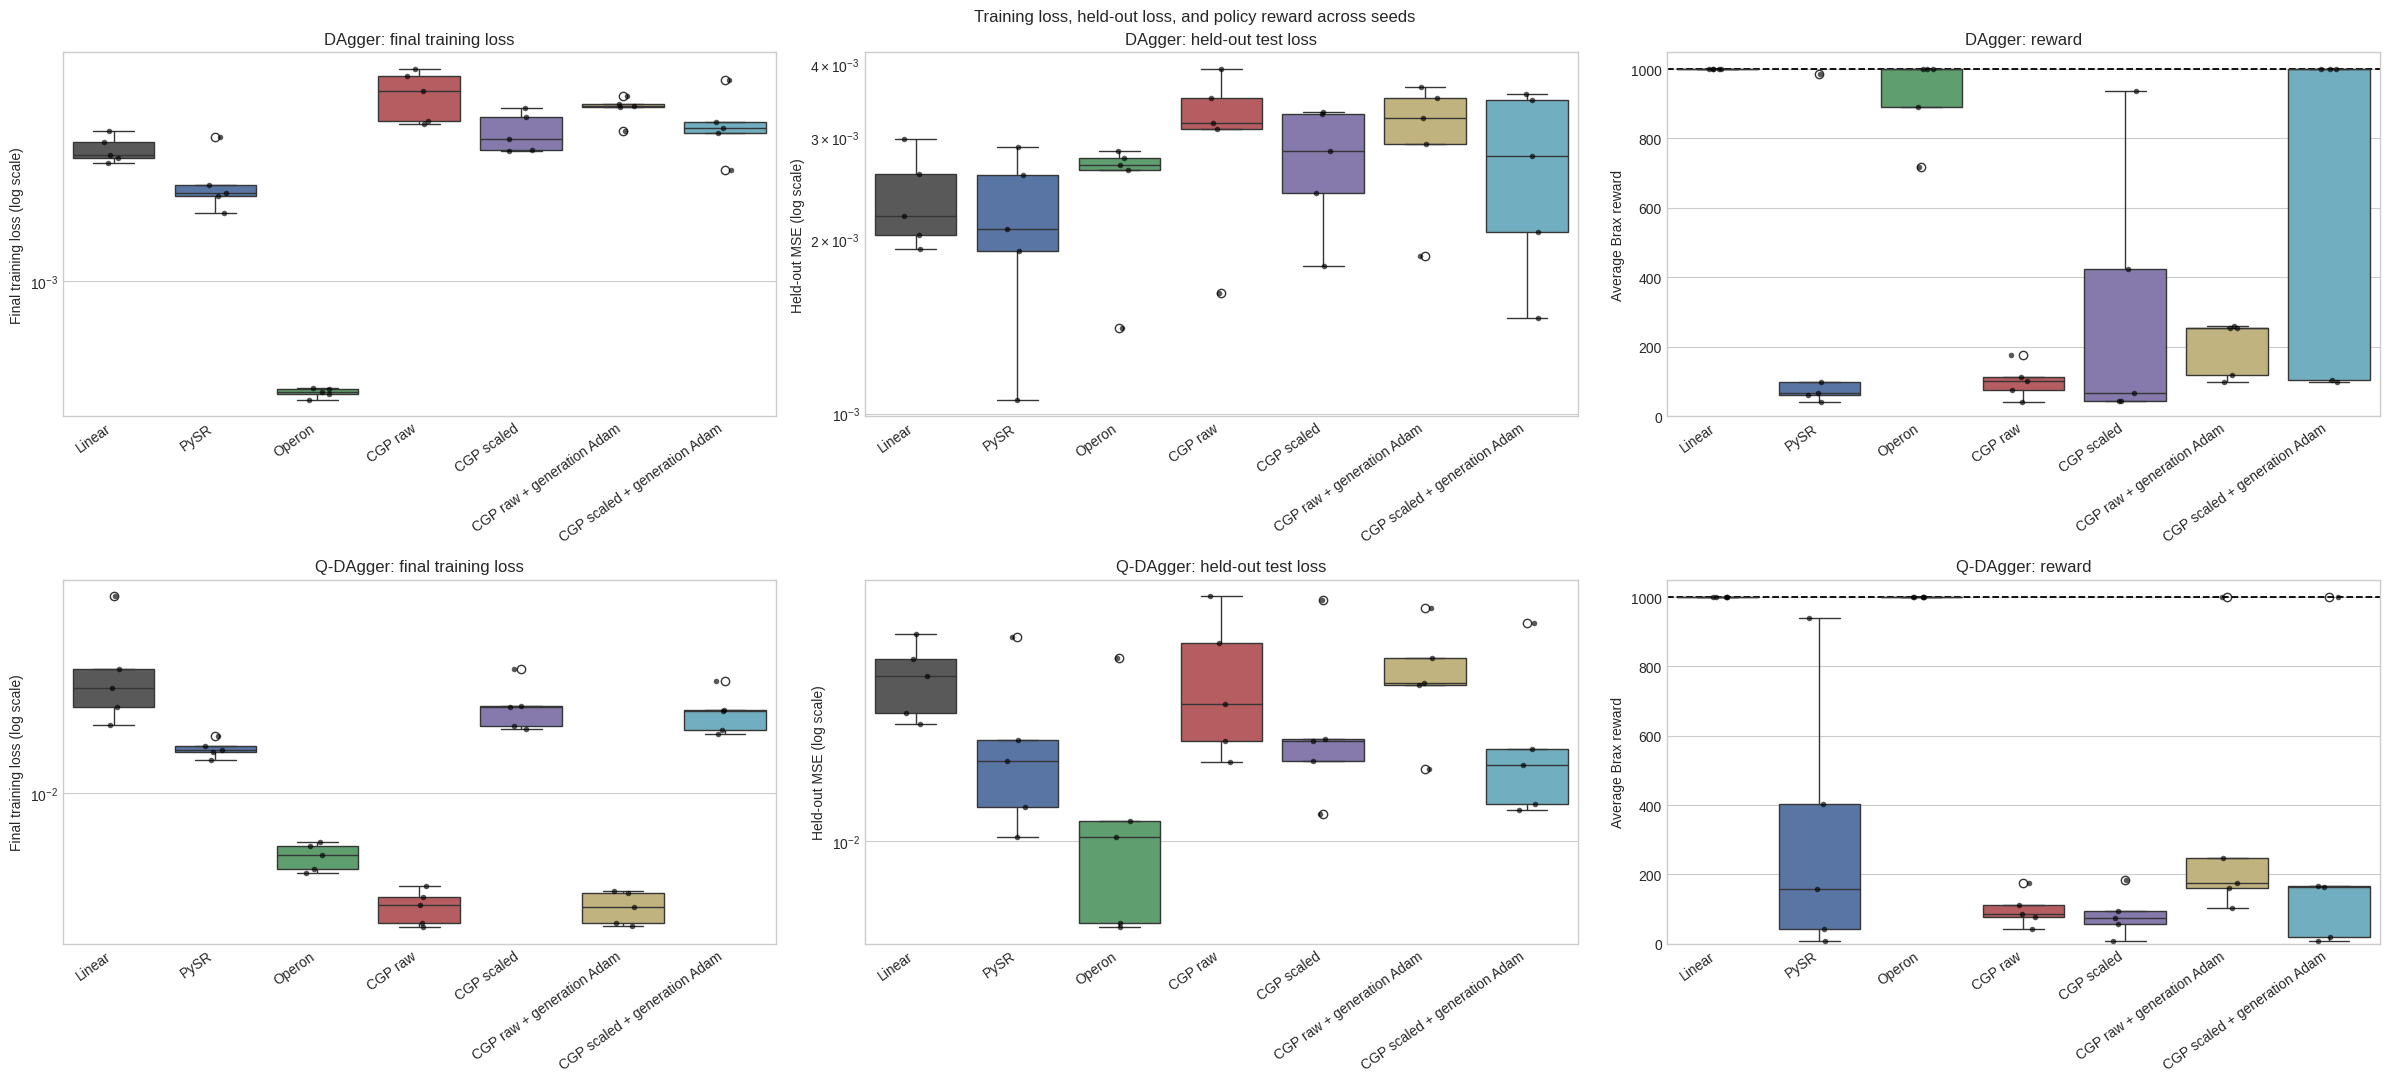

In [4]:
test_frames = []
for method, policy in reward_policy_map.items():
    frame = comparison[(comparison.policy == policy) & comparison.test_loss.notna()][['weighting', 'seed', 'test_loss']].copy()
    frame = frame.rename(columns={'test_loss': 'loss'})
    frame['method'] = method
    test_frames.append(frame)
test_loss_distribution = pd.concat(test_frames, ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(24, 11))
for row_index, weighting in enumerate(['DAgger', 'Q-DAgger']):
    panels = [
        (axes[row_index, 0], final_loss_distribution[final_loss_distribution.weighting == weighting], 'loss', f'{weighting}: final training loss', 'Final training loss (log scale)', True),
        (axes[row_index, 1], test_loss_distribution[test_loss_distribution.weighting == weighting], 'loss', f'{weighting}: held-out test loss', 'Held-out MSE (log scale)', True),
        (axes[row_index, 2], reward_distribution[reward_distribution.weighting == weighting], 'reward', f'{weighting}: reward', 'Average Brax reward', False),
    ]
    for ax, data, value, title, ylabel, use_log in panels:
        order = [method for method in method_order if method in set(data.method)]
        sns.boxplot(data=data, x='method', y=value, order=order, palette=box_colors, showfliers=True, whis=1.5, ax=ax)
        sns.stripplot(data=data, x='method', y=value, order=order, color='black', size=4, alpha=0.65, jitter=0.12, ax=ax)
        if use_log:
            ax.set_yscale('log')
        else:
            ax.axhline(999, color='black', linestyle='--', linewidth=1.3)
            ax.set_ylim(bottom=0)
        ax.set(title=title, xlabel='', ylabel=ylabel)
        ax.tick_params(axis='x', rotation=35)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment('right')
fig.suptitle('Training loss, held-out loss, and policy reward across seeds')
plt.tight_layout(); plt.show()

# Policy smoothness and feedback shape

Uniform-weighted linear, PySR, Operon and scaled CGP with per-generation Adam. Diagnostics use executed actions, including clipping.


In [5]:
import pickle
import sympy
import jax
import jax.numpy as jnp
from distillation.fit_imitation import apply_linear_scaling
from distillation.rollouts import sanitize_action
from distillation_experiments.scripts.experiments.operon_imitation import expression_to_jax
from genepax.gp.cartesian_genetic_programming import CGP

expert = np.load(EXP / 'artifacts' / 'expert_datasets/expert_inverted_pendulum.npz')
expert_X = np.asarray(expert['X'], dtype=np.float32)
state_center = np.median(expert_X, axis=0)
state_scale = np.std(expert_X, axis=0)
state_names = ['Cart position', 'Pole angle', 'Cart velocity', 'Pole angular velocity']

pysr_uniform = pysr_results[pysr_results['mode'] == 'uniform'].set_index('seed')
operon_uniform = operon_results[operon_results['mode'] == 'uniform'].set_index('seed')
smoothness_policies = {}
for seed in range(5):
    linear_model = np.load(LINEAR_DIR / f'seed_{seed}/final_model.npz')
    coef = jnp.asarray(linear_model['coefficients']); intercept = jnp.asarray(linear_model['intercept'])
    smoothness_policies[('Linear', seed)] = lambda X, coef=coef, intercept=intercept: sanitize_action(X @ coef.T + intercept)

    symbols = sympy.symbols('x0:4')
    equation = sympy.sympify(pysr_uniform.loc[seed, 'equation'], locals={str(symbol): symbol for symbol in symbols} | {'tanh': sympy.tanh})
    pysr_fn = sympy.lambdify(symbols, equation, modules='jax')
    smoothness_policies[('PySR', seed)] = lambda X, fn=pysr_fn: sanitize_action(jnp.asarray(fn(*X.T)).reshape(-1, 1))

    operon_fn = expression_to_jax(operon_uniform.loc[seed, 'expression'], expert_X.shape[1])
    smoothness_policies[('Operon', seed)] = lambda X, fn=operon_fn: sanitize_action(jax.vmap(lambda row: jnp.atleast_1d(fn(*row)))(X))

    genotype_path = GEN_ADAM_DIR / f'seed_{seed}/scaled/best_individual.pickle'
    with genotype_path.open('rb') as file:
        genotype = pickle.load(file)
    cgp = CGP(n_inputs=expert_X.shape[1], n_outputs=1, weighted_inputs=True, n_custom_weights=2)
    smoothness_policies[('CGP scaled + generation Adam', seed)] = lambda X, genotype=genotype, cgp=cgp: sanitize_action(apply_linear_scaling(jax.vmap(cgp.apply, in_axes=(None, 0))(genotype, X), genotype['weights']['custom_weights']))

smoothness_methods = ['Linear', 'PySR', 'Operon', 'CGP scaled + generation Adam']
smoothness_colors = {method: box_colors[method] for method in smoothness_methods}


## Local sensitivity and feedback strength

Sensitivity is action change per normalized state perturbation (2%). Gains are measured near the median expert state. Five seeds per method.


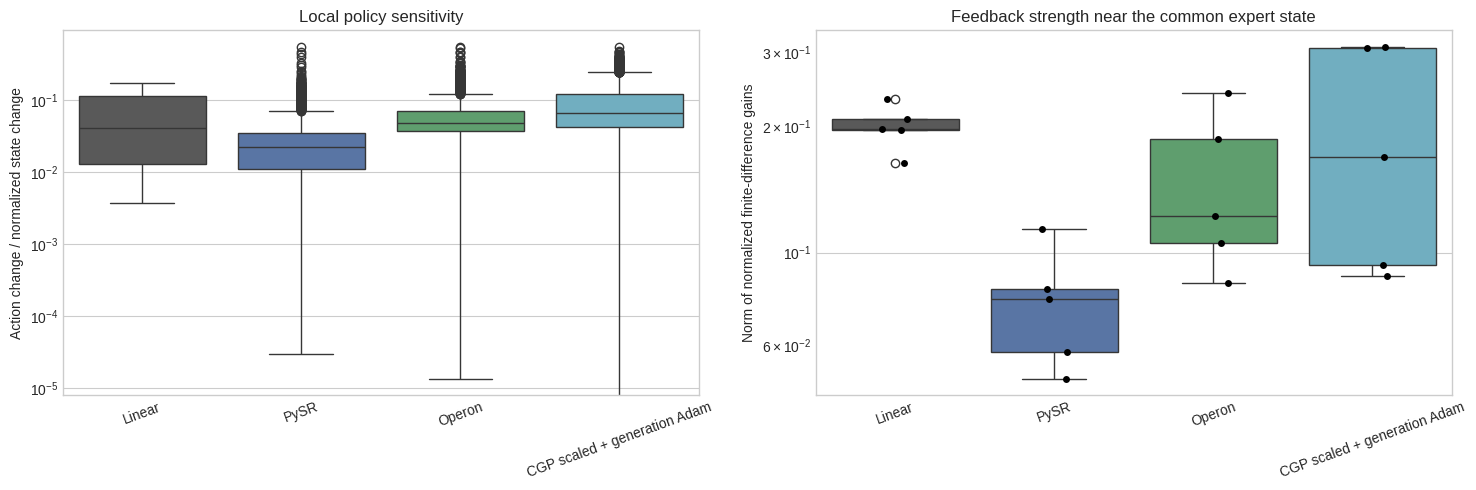

In [6]:
rng = np.random.default_rng(17)
sample_states = expert_X[rng.choice(len(expert_X), size=750, replace=False)]
directions = rng.normal(size=(8, expert_X.shape[1]))
directions /= np.linalg.norm(directions, axis=1, keepdims=True)
epsilon = 0.02
sensitivity_rows, gain_rows = [], []
for (method, seed), policy in smoothness_policies.items():
    for direction in directions:
        delta = epsilon * state_scale * direction
        plus = np.asarray(policy(jnp.asarray(sample_states + delta)))[:, 0]
        minus = np.asarray(policy(jnp.asarray(sample_states - delta)))[:, 0]
        values = np.abs(plus - minus) / (2 * epsilon)
        sensitivity_rows.extend({'method': method, 'seed': seed, 'sensitivity': value} for value in values)
    gains = []
    for coordinate in range(expert_X.shape[1]):
        delta = np.zeros(expert_X.shape[1]); delta[coordinate] = epsilon * state_scale[coordinate]
        plus = float(np.asarray(policy(jnp.asarray((state_center + delta)[None, :])))[0, 0])
        minus = float(np.asarray(policy(jnp.asarray((state_center - delta)[None, :])))[0, 0])
        gains.append((plus - minus) / (2 * epsilon))
    gain_rows.append({'method': method, 'seed': seed, 'gain_norm': np.linalg.norm(gains),
                     **dict(zip(state_names, gains))})
sensitivity = pd.DataFrame(sensitivity_rows)
feedback_gains = pd.DataFrame(gain_rows)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=sensitivity, x='method', y='sensitivity', order=smoothness_methods,
            palette=smoothness_colors, showfliers=True, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set(title='Local policy sensitivity', xlabel='', ylabel='Action change / normalized state change')
sns.boxplot(data=feedback_gains, x='method', y='gain_norm', order=smoothness_methods,
            palette=smoothness_colors, showfliers=True, ax=axes[1])
sns.stripplot(data=feedback_gains, x='method', y='gain_norm', order=smoothness_methods,
              color='black', jitter=.1, size=5, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set(title='Feedback strength near the common expert state', xlabel='', ylabel='Norm of normalized finite-difference gains')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

## One-coordinate response curves

One coordinate varies over its 1st–99th expert-data percentile range; the other coordinates remain at their medians. Lines show seed medians and shading spans seeds.


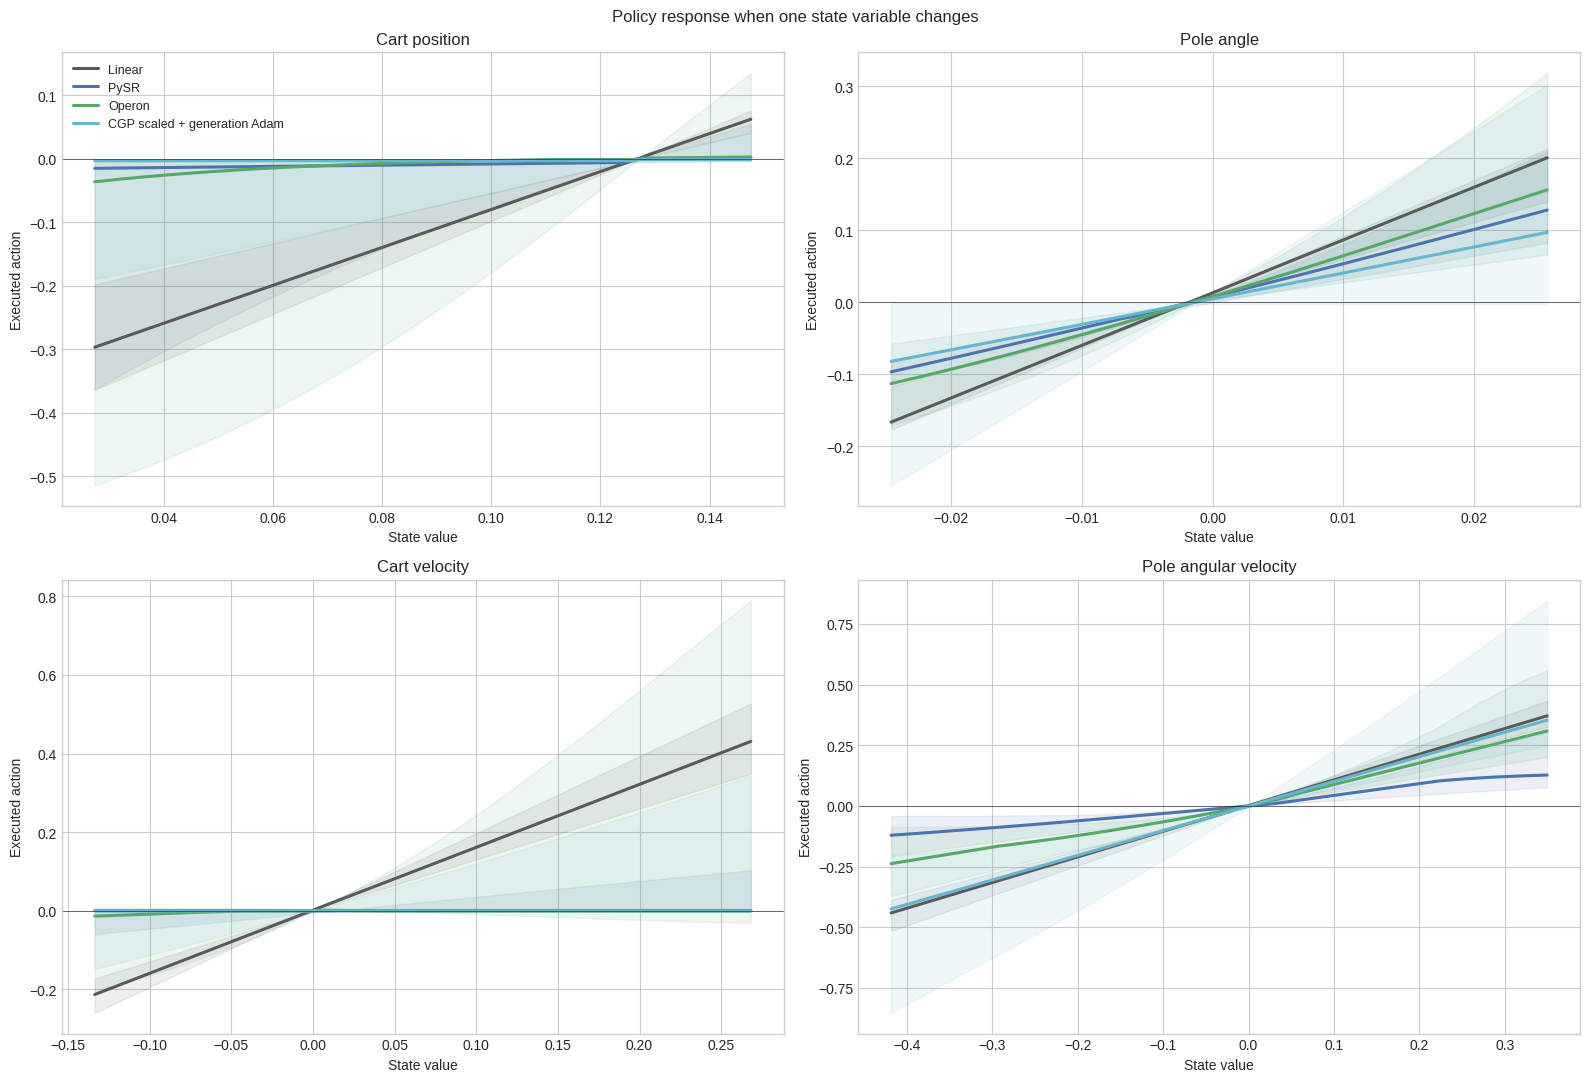

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for coordinate, ax in enumerate(axes.flat):
    values = np.linspace(*np.quantile(expert_X[:, coordinate], [.01, .99]), 160)
    states = np.repeat(state_center[None, :], len(values), axis=0)
    states[:, coordinate] = values
    for method in smoothness_methods:
        actions = np.stack([np.asarray(smoothness_policies[(method, seed)](jnp.asarray(states)))[:, 0] for seed in range(5)])
        ax.plot(values, np.median(actions, axis=0), color=smoothness_colors[method], linewidth=2.2, label=method)
        ax.fill_between(values, actions.min(axis=0), actions.max(axis=0), color=smoothness_colors[method], alpha=.1)
    ax.axhline(0, color='black', linewidth=.7, alpha=.5)
    ax.set(title=state_names[coordinate], xlabel='State value', ylabel='Executed action')
axes[0, 0].legend(fontsize=9)
fig.suptitle('Policy response when one state variable changes')
plt.tight_layout(); plt.show()

## Pole recovery maps

Executed actions over pole angle and angular velocity for seed 2. Cart position and velocity are held fixed.


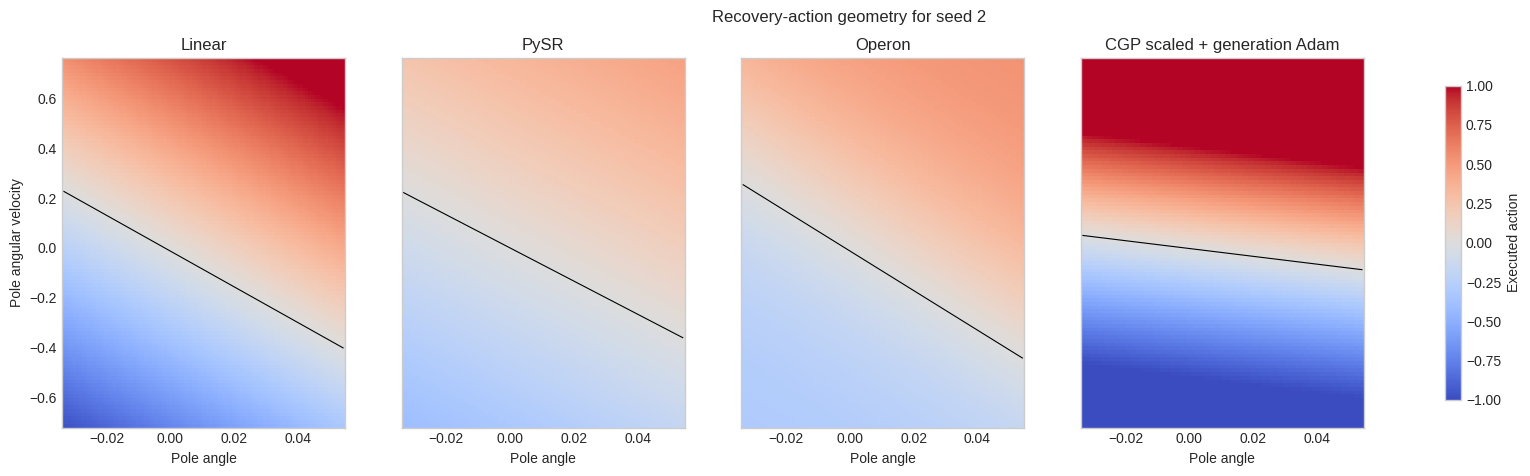

In [8]:
angle_values = np.linspace(*np.quantile(expert_X[:, 1], [.005, .995]), 100)
angular_velocity_values = np.linspace(*np.quantile(expert_X[:, 3], [.005, .995]), 100)
angle_grid, velocity_grid = np.meshgrid(angle_values, angular_velocity_values)
grid_states = np.repeat(state_center[None, :], angle_grid.size, axis=0)
grid_states[:, 1] = angle_grid.ravel(); grid_states[:, 3] = velocity_grid.ravel()
fig, axes = plt.subplots(1, 4, figsize=(21, 4.8), sharex=True, sharey=True)
for ax, method in zip(axes, smoothness_methods):
    action_grid = np.asarray(smoothness_policies[(method, 2)](jnp.asarray(grid_states)))[:, 0].reshape(angle_grid.shape)
    image = ax.pcolormesh(angle_grid, velocity_grid, action_grid, shading='auto', cmap='coolwarm', vmin=-1, vmax=1)
    ax.contour(angle_grid, velocity_grid, action_grid, levels=[0], colors='black', linewidths=.8)
    ax.set(title=method, xlabel='Pole angle')
axes[0].set_ylabel('Pole angular velocity')
fig.colorbar(image, ax=axes, label='Executed action', shrink=.85)
fig.suptitle('Recovery-action geometry for seed 2')
plt.show()

## Trajectory roughness

Valid transitions from 300-step Generalized-backend rollouts. Total variation measures consecutive action changes; jerk measures changes in those changes.


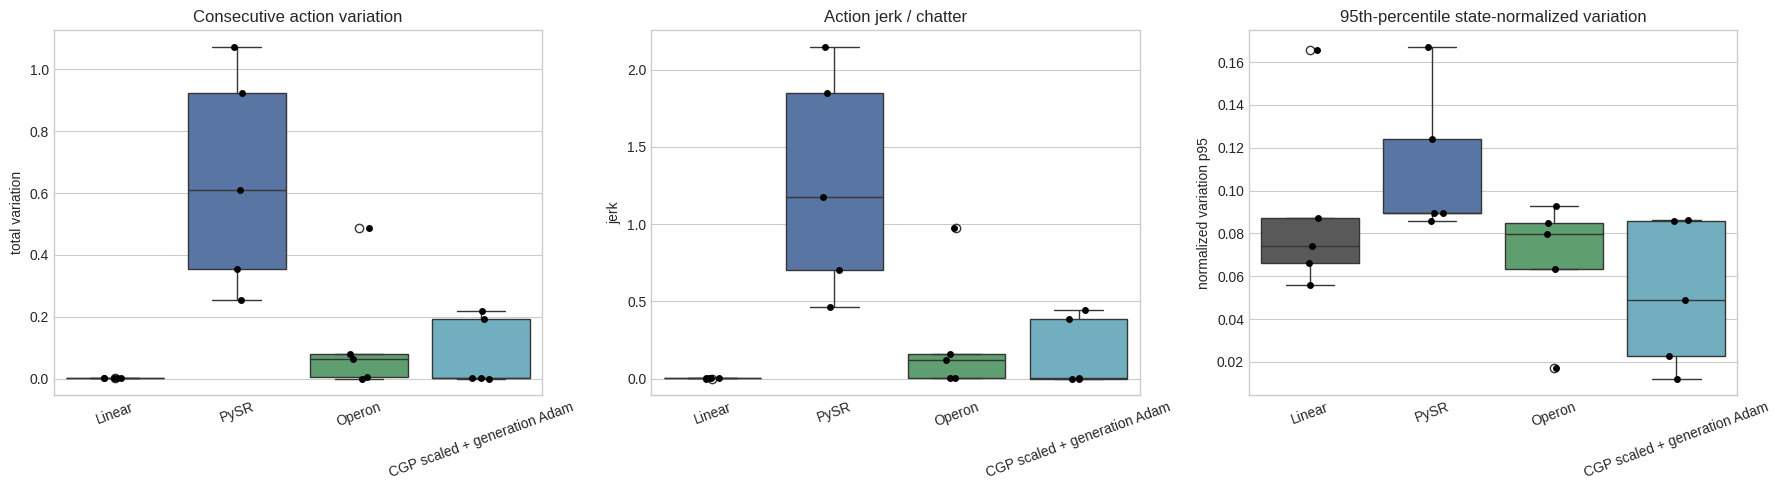

In [9]:
from brax import envs
from distillation.rollouts import rollout, valid_transition_mask
roughness_rows = []
environment = envs.get_environment('inverted_pendulum', backend='generalized')
for (method, seed), policy in smoothness_policies.items():
    def action_fn(observation, _key, _step, policy=policy):
        action = policy(observation[None, :])[0]
        return action, action
    observations, actions, rewards, dones = rollout(environment, jax.random.key(70000 + seed), action_fn, 300)
    observations = np.asarray(observations); actions = np.asarray(actions)[:, 0]
    valid = np.asarray(valid_transition_mask(dones)).astype(bool)
    observations = observations[valid]; actions = actions[valid]
    action_delta = np.abs(np.diff(actions))
    state_delta = np.linalg.norm(np.diff(observations / state_scale, axis=0), axis=1)
    normalized_variation = action_delta / np.maximum(state_delta, 1e-8)
    roughness_rows.append({'method': method, 'seed': seed, 'lifetime': len(actions),
                          'total_variation': action_delta.mean() if len(action_delta) else np.nan,
                          'jerk': np.abs(np.diff(actions, n=2)).mean() if len(actions)>2 else np.nan,
                          'normalized_variation_p95': np.quantile(normalized_variation, .95) if len(normalized_variation) else np.nan})
trajectory_roughness = pd.DataFrame(roughness_rows)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(axes, ['total_variation', 'jerk', 'normalized_variation_p95'],
                            ['Consecutive action variation', 'Action jerk / chatter', '95th-percentile state-normalized variation']):
    sns.boxplot(data=trajectory_roughness, x='method', y=metric, order=smoothness_methods,
                palette=smoothness_colors, showfliers=True, ax=ax)
    sns.stripplot(data=trajectory_roughness, x='method', y=metric, order=smoothness_methods,
                  color='black', size=5, jitter=.1, ax=ax)
    ax.set(title=title, xlabel='', ylabel=metric.replace('_', ' ')); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

# CGP feedback gains and recovery geometry

Raw/scaled CGP with per-generation Adam, both weightings and five seeds. Gains use normalized state coordinates; stars mark solved policies.


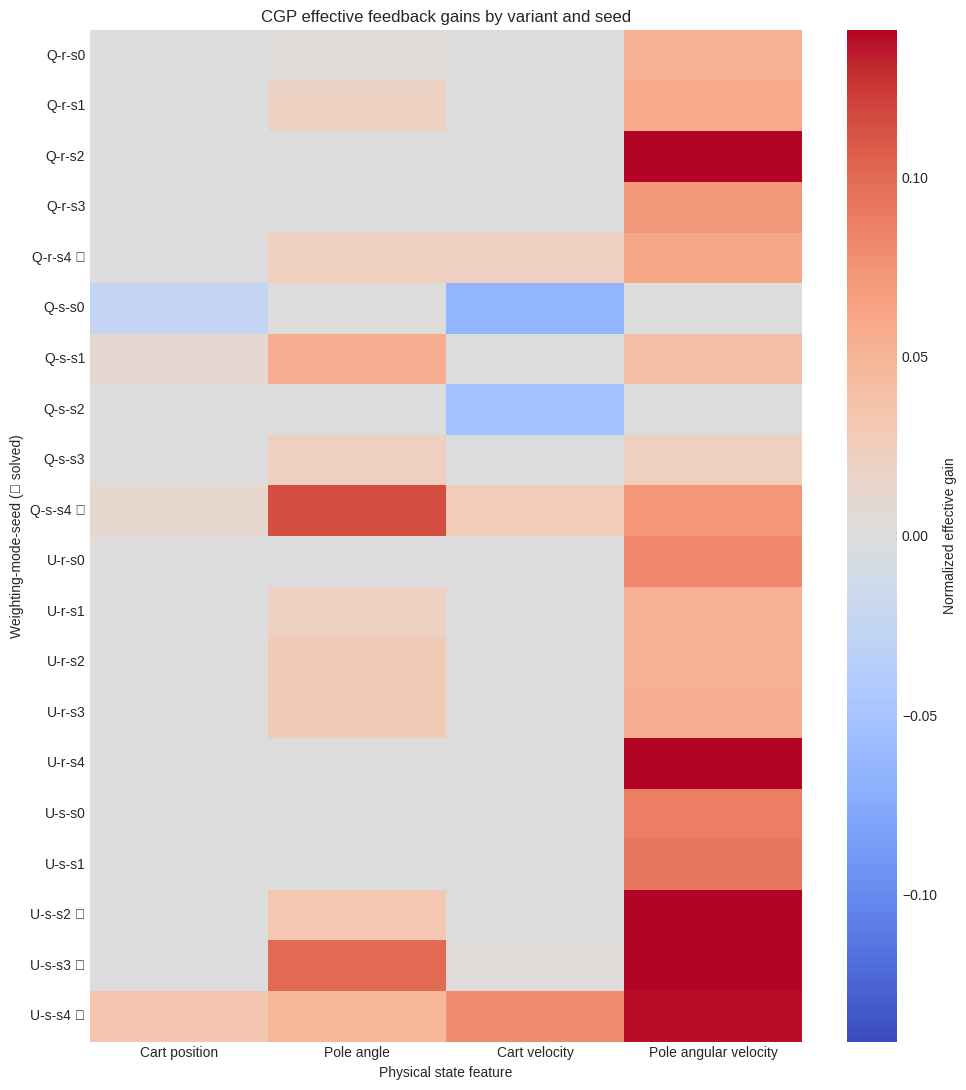

In [10]:
cgp_policies, cgp_rows, summary_lookup = {}, [], {}
for weighting, frame in [('Uniform', generation_adam), ('Q-DAgger', q_generation_adam)]:
    for row in frame.itertuples():
        summary_lookup[(weighting, row.mode, row.seed)] = row
for weighting, root in [('Uniform', GEN_ADAM_DIR), ('Q-DAgger', Q_GEN_ADAM_DIR)]:
    for mode in ['raw', 'scaled']:
        for seed in range(5):
            with (root / f'seed_{seed}' / mode / 'best_individual.pickle').open('rb') as file:
                genotype = pickle.load(file)
            cgp = CGP(n_inputs=4, n_outputs=1, weighted_inputs=True, n_custom_weights=2 if mode=='scaled' else 0)
            def policy(X, genotype=genotype, cgp=cgp, scaled=(mode=='scaled')):
                raw = jax.vmap(cgp.apply, in_axes=(None, 0))(genotype, X)
                if scaled:
                    raw = apply_linear_scaling(raw, genotype['weights']['custom_weights'])
                return sanitize_action(raw)
            cgp_policies[(weighting, mode, seed)] = policy
grid_angle = np.linspace(*np.quantile(expert_X[:, 1], [.005, .995]), 80)
grid_velocity = np.linspace(*np.quantile(expert_X[:, 3], [.005, .995]), 80)
grid_A, grid_V = np.meshgrid(grid_angle, grid_velocity)
cgp_grid_states = np.repeat(state_center[None, :], grid_A.size, axis=0)
cgp_grid_states[:, 1] = grid_A.ravel(); cgp_grid_states[:, 3] = grid_V.ravel()
def normalized_gains(policy):
    gains = []
    for coordinate in range(4):
        delta = np.zeros(4); delta[coordinate] = .02 * state_scale[coordinate]
        plus = float(np.asarray(policy(jnp.asarray((state_center + delta)[None, :])))[0, 0])
        minus = float(np.asarray(policy(jnp.asarray((state_center - delta)[None, :])))[0, 0])
        gains.append((plus - minus) / .04)
    return np.asarray(gains)
for (weighting, mode, seed), policy in cgp_policies.items():
    gains = normalized_gains(policy)
    linear_policy = smoothness_policies[('Linear', seed)]
    linear_gains = normalized_gains(linear_policy)
    cgp_actions = np.asarray(policy(jnp.asarray(cgp_grid_states)))[:, 0].reshape(grid_A.shape)
    linear_actions = np.asarray(linear_policy(jnp.asarray(cgp_grid_states)))[:, 0].reshape(grid_A.shape)
    summary_row = summary_lookup[(weighting, mode, seed)]
    cgp_rows.append({'weighting': weighting, 'mode': mode, 'seed': seed,
        'reward': summary_row.best_reward_after_adam, 'solved': bool(summary_row.solved),
        'gain_alignment': np.dot(gains, linear_gains) / max(np.linalg.norm(gains)*np.linalg.norm(linear_gains), 1e-12),
        'gain_norm_ratio': np.linalg.norm(gains) / max(np.linalg.norm(linear_gains), 1e-12),
        'recovery_map_rmse': np.sqrt(np.mean((cgp_actions-linear_actions)**2)),
        'saturation_fraction': np.mean(np.abs(cgp_actions)>=.95),
        'max_neighbor_jump': max(np.abs(np.diff(cgp_actions, axis=1)).max(), np.abs(np.diff(cgp_actions, axis=0)).max()),
        **dict(zip(state_names, gains))})
cgp_diagnostics = pd.DataFrame(cgp_rows)
cgp_diagnostics['variant'] = cgp_diagnostics.weighting + ' · ' + cgp_diagnostics['mode']
ordered = cgp_diagnostics.sort_values(['weighting', 'mode', 'seed']).reset_index(drop=True)
gain_matrix = ordered[state_names].to_numpy()
gain_limit = np.quantile(np.abs(gain_matrix), .95)
row_labels = [f"{row.weighting[:1]}-{row['mode'][0]}-s{row.seed}{' ★' if row.solved else ''}" for _, row in ordered.iterrows()]
fig, ax = plt.subplots(figsize=(10, 11))
sns.heatmap(gain_matrix, center=0, cmap='coolwarm', vmin=-gain_limit, vmax=gain_limit,
            xticklabels=state_names, yticklabels=row_labels, ax=ax, cbar_kws={'label':'Normalized effective gain'})
ax.set(title='CGP effective feedback gains by variant and seed', xlabel='Physical state feature', ylabel='Weighting-mode-seed (★ solved)')
plt.tight_layout(); plt.show()

## Feedback properties versus reward

Each point is one policy. Metrics compare gain alignment, recovery-map error, saturation and neighboring action changes with rollout reward.


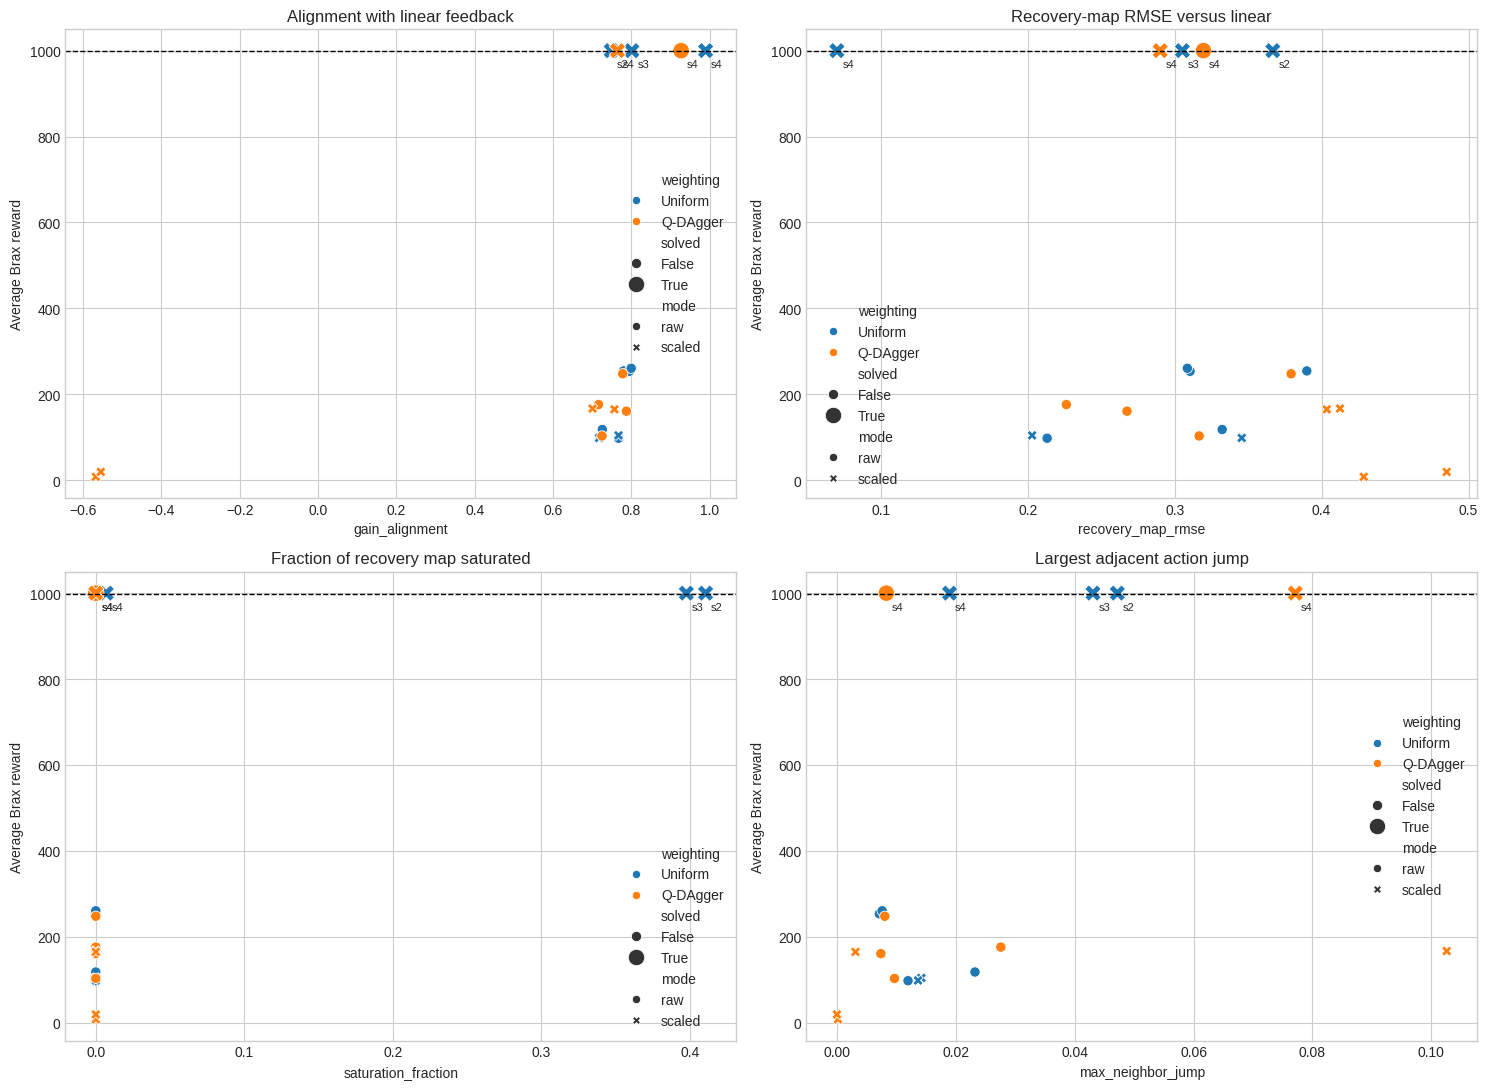

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
metrics = [('gain_alignment', 'Alignment with linear feedback'), ('recovery_map_rmse', 'Recovery-map RMSE versus linear'),
           ('saturation_fraction', 'Fraction of recovery map saturated'), ('max_neighbor_jump', 'Largest adjacent action jump')]
for ax, (metric, title) in zip(axes.flat, metrics):
    sns.scatterplot(data=cgp_diagnostics, x=metric, y='reward', hue='weighting', style='mode',
                    size='solved', sizes={False:55, True:140}, ax=ax)
    ax.axhline(999, color='black', linestyle='--', linewidth=1)
    for row in cgp_diagnostics.itertuples():
        if row.solved:
            ax.annotate(f's{row.seed}', (getattr(row, metric), row.reward), xytext=(4,-12), textcoords='offset points', fontsize=8)
    ax.set(title=title, ylabel='Average Brax reward')
plt.tight_layout(); plt.show()

## Representative recovery maps

Solved and failed scaled policies under both weightings, shown on the same state range.


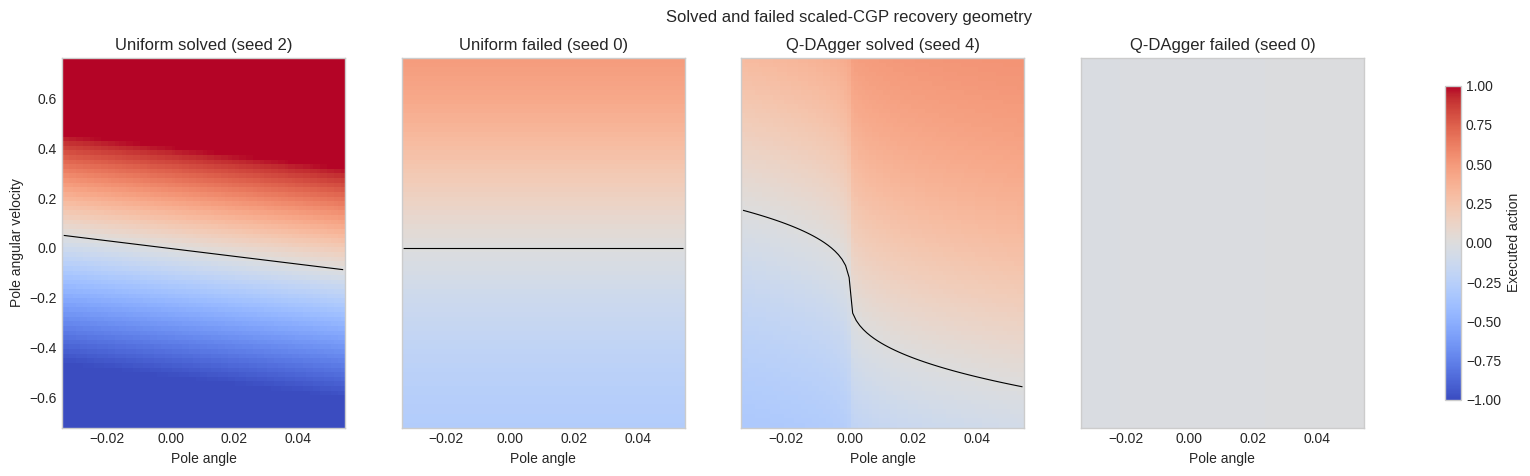

In [12]:
representatives = [('Uniform', 'scaled', 2, 'Uniform solved (seed 2)'), ('Uniform', 'scaled', 0, 'Uniform failed (seed 0)'),
                   ('Q-DAgger', 'scaled', 4, 'Q-DAgger solved (seed 4)'), ('Q-DAgger', 'scaled', 0, 'Q-DAgger failed (seed 0)')]
fig, axes = plt.subplots(1, 4, figsize=(21, 4.8), sharex=True, sharey=True)
for ax, (weighting, mode, seed, title) in zip(axes, representatives):
    values = np.asarray(cgp_policies[(weighting, mode, seed)](jnp.asarray(cgp_grid_states)))[:, 0].reshape(grid_A.shape)
    image = ax.pcolormesh(grid_A, grid_V, values, shading='auto', cmap='coolwarm', vmin=-1, vmax=1)
    ax.contour(grid_A, grid_V, values, levels=[0], colors='black', linewidths=.8)
    ax.set(title=title, xlabel='Pole angle')
axes[0].set_ylabel('Pole angular velocity')
fig.colorbar(image, ax=axes, label='Executed action', shrink=.85)
fig.suptitle('Solved and failed scaled-CGP recovery geometry')
plt.show()